In [160]:
import pandas as pd
import numpy as np
import requests

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


[тут будет вводная какая-то]

колонка "Строительная готовность" не обработана, там пропуски у новостроек а она оч важная, также

колонка "метро" не обработана (не уверен как лучше заполнять пропуски, коих оч много, и колонка мегаважная)

и колонка "время до метро" не обработана



Разместим наш dataframe на гугл диске, для простоты открытия, и посмотрим на него

In [161]:
url = ('https://drive.google.com/file/d/1jPoyNu4NpFxyJoFabDW0XhGhBKD8Gibs/view?usp=sharing')
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df = pd.read_csv(url, sep=';')

/tmp/ipykernel_1039/1644506055.py:3: DtypeWarning: Columns (19,45,58,60,64) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, sep=';')


In [162]:
print(df.head(5))

                                                       Адрес  Площадь  \
0                         Москва, 2-й Иртышский проезд, к1/4  59,6 м²   
1  Москва, пос. Коммунарка, улица Александры Монаховой, к1/4  72,2 м²   
2                              Москва, Кварцевая улица, 2 к4  59,4 м2   
3       Москва, Матвеевское м-н, Староволынская улица, 12 к3    65 м2   
4          Москва, пос. Коммунарка, улица Липовый парк, 4 к3  71,6 м2   

     Жилая    Кухня Класс жилья   Отделка  Комнат Вид из окна  \
0  21,8 м²  20,5 м²      Бизнес  Чистовая     2.0       Улица   
1  34,7 м²  15,7 м²     Комфорт  Чистовая     3.0        Двор   
2      NaN  19,4 м2         NaN       NaN     2.0         NaN   
3    30 м2    10 м2         NaN       NaN     2.0         NaN   
4  34,9 м2  17,2 м2         NaN       NaN     2.0         NaN   

   Санузел совмещён  Подъезд  ... Европланировка Теплоснабжение  \
0               2.0      5.0  ...            NaN            NaN   
1               2.0      3.0  ...   

In [163]:
df.shape

(10481, 68)

Видим, что у нас 67 признаков
Займёмся удалением лишних столбцов, которые не несут для нас ценной информации.

Важно, что нам следует оставить признаки, которые могут быть полезны именно для определения цены на квартиру

Таким образом, "Мусором" будет:

Адрес (по нему у нас есть информация по инфраструктуе, в т.ч. метро, поэтому он лишний и не несёт в себе информации)

Подъезд (номер подъезда)

Балкон, балконы, лоджия и лоджии (информация внесена в признак "Количетсво балконов")

ВсегоКвартирвпродаже

Финансируется ли Сбербанком

Материал стен (дублирует колонку материалстен)

Количество этажей (колонка дублируется)

Количество подъездов

Квартира (номер квартиры)

Лифт (в 100% объектах значение равно "есть" т.е. неинформативный признак)

Серия дома (это косвенно определяет ряд другиз признаков, но само не влияет на цену, и серий домов очень большое множество)

Тип фундамента

Прописано (неинформативная колонка)

Вид из окон (т.к. дублирует колонку Вид из окна и даёт информацию по целому дому)

Санузел (дублирует информацию из колонки Санузел совмещён)

Количество лифтов (т.к. это зависит почти всегда только от признака Количество Этажей и вычисл. по формуле, т.е. признак лишний)

Несовершеннолетние собственники, Прописанные несовершеннолетние - юридические данные и почти не влияет на цену

Наименьшее кол-во этажей, холод. водоснаб., санузел отдельно, лоджия, детская площадка, европланировка, теплоснабжение, энергоснабжение, балкон, спортивная площадка, лоджии, водоотведение, Класс энергоэффективности, Количество собственников, Год ввода в эксплуатацию - мусорные данные которые могут ухудшить нашу модель ввиду неинформативности/отсутствия данных в 90%+ и более объектах

Количество балконов, мусоропровод - отсутствуют более чем в 75% объектах, решено удалить



In [164]:
cols_to_drop = ['Адрес','Подъезд',
'Балкон','Балконы','Лоджия','Лоджии',
'Всегоквартирв продаже','ФинансируетсяСберБанком','Материал стен','Количество этажей','Количество подъездов',
'Квартира','Лифт','Серия дома','Тип фундамента','Прописано','Несовершеннолетние собственники','Прописанные несовершеннолетние',
'Наименьшее количество этажей','Холодное водоснабжение','Санузел отдельно','Детская площадка','Европланировка','Теплоснабжение',
'Энергоснабжение','Спортивная площадка','Водоотведение','Класс энергоэффективности', 'Вид из окон', 'Санузел', 'Количество лифтов',
'Количество собственников', 'Горячее водоснабжение', 'Количество балконов', 'Мусоропровод', "Год ввода в эксплуатацию"]

df = df.drop(columns=cols_to_drop)

In [165]:
df.shape

(10481, 32)

In [166]:
df.to_csv('data_clean2.csv', index=False, encoding='utf-8-sig',sep=';')

Теперь займёмся обработкой каждого поля по-отдельности

Для начала заполним пропуски в данных

Для заполнения ячеек "Жилая площадь" и "Кухня" попробуем определить зависимость от площади квартиры (находим коэф. и заполняем пропуски путём перемножения этого коэфа на площадь квартиры)

In [167]:
cols = ['Площадь', 'Жилая', 'Кухня']

for col in cols:
    df[col] = pd.to_numeric(df[col].replace({'м²': '', 'м2': '', ',': '.'}, regex=True))

# коэффициент для жилой и кухни
coef_living = (df.loc[df['Жилая'].notna(), 'Жилая']/df.loc[df['Жилая'].notna(),'Площадь']).mean()
coef_kitchen = (df.loc[df['Кухня'].notna(), 'Кухня']/df.loc[df['Кухня'].notna(),'Площадь']).mean()

print(coef_living)

df.loc[df['Жилая'].isna(), 'Жилая'] = (df.loc[df['Жилая'].isna(),'Площадь'] * coef_living).round().astype(int)
df.loc[df['Кухня'].isna(), 'Кухня'] = (df.loc[df['Кухня'].isna(),'Площадь'] * coef_kitchen).round().astype(int)

df['Жилая'] = pd.to_numeric(df['Жилая'])
df['Кухня'] = pd.to_numeric(df['Кухня'])

0.5258359163106483


для признака "класс жилья" заполним пропуски модой (самым встреч. знач), а также используем label encoding для кодировки этого признака

In [168]:
classZhil = {'Стандарт':1,'Комфорт':2,'Бизнес':3,'Премиум':4}
df['Класс жилья'] = df['Класс жилья'].fillna(df['Класс жилья'].mode()[0])

df['Класс жилья'] = df['Класс жилья'].map(classZhil)

Признак "Ремонт" объединим с признаком "Отделка", создав новый признак "Состояние" (пропусков в признаках ремонт/отделка нет)


In [169]:
text = df['Ремонт'].astype(str) + ' ' + df['Отделка'].astype(str)

df['Состояние'] = 'Средний'
df.loc[text.str.contains('без'), 'Состояние'] = 'Без ремонта'
df.loc[text.str.contains('требует'), 'Состояние'] = 'Без ремонта'
df.loc[text.str.contains('чернов'), 'Состояние'] = 'Без ремонта'
df.loc[text.str.contains('предчист'), 'Состояние'] = 'Предчистовая'
df.loc[text.str.contains('космет'), 'Состояние'] = 'Косметический'
df.loc[text.str.contains('евро'), 'Состояние'] = 'Евроремонт'
df.loc[text.str.contains('дизайн'), 'Состояние'] = 'Евроремонт'
df.loc[text.str.contains('чист') & (text.str.contains('предчист') == False), 'Состояние'] = 'Чистовая'

In [170]:
remont_map = {'Без ремонта': 0, 'Предчистовая': 1, 'Средний': 2, 'Косметический': 3, 'Чистовая': 4, 'Евроремонт': 5}

df['Состояние'] = df['Состояние'].map(remont_map)

cols_droping = ['Ремонт','Отделка'] #удаляем теперь уже лишние колонки
df = df.drop(columns=cols_droping)

Строки с пропущенным признаком "Комнат" было решено удалить, т.к. он предоставляет большое значение для нас, и мы не можем заполнить пропуски с кол-вом комнат каким-либо значением, это может сильно испортить нашу модель (пропусков менее 10% от всех данных)

In [171]:
print(df['Комнат'].isna().sum())
df = df.dropna(subset=['Комнат'])
print(df['Комнат'].isna().sum())

df['Комнат'] = pd.to_numeric(df['Комнат'])

869
0


Заполним пропуски в колонке "Вид из окна" модой, а также закодируем с помощью OHE, т.к. для нас это важный признак и он может сильно влиять на цену (при этом это не ранговый столбец, т.к. в некоторых случаях вид на двор лучше чем вид на улицу, например, если на улице ж/д пути или трасса)

In [172]:
df['Вид из окна'] = df['Вид из окна'].fillna(df['Вид из окна'].mode()[0])
df = pd.get_dummies(df, columns=['Вид из окна'], dtype=int, drop_first=True)

Также обработаем ряд других, менее важных (по степени влияния на цену) признаков:

Кол-во санузлов больше всего зависит от площади квартиры и кол-во комнат, попробуем определить зависимость и заполнить пропуски с помощью линейной регрессии


In [173]:
#df['Санузел совмещён'] = df['Санузел совмещён'].fillna(df['Санузел совмещён'].mode()[0]) #заполняем кол-во туалетов самым встречающимся кол-во
#print(df.loc[df['Санузел совмещён'] == 3, 'Площадь'].quantile(0.25), df.loc[df['Санузел совмещён'] == 3, 'Площадь'].quantile(0.75))
#print(df.loc[df['Санузел совмещён'] == 2, 'Площадь'].quantile(0.25), df.loc[df['Санузел совмещён'] == 2, 'Площадь'].quantile(0.75))
#print(df.loc[df['Санузел совмещён'] == 1, 'Площадь'].quantile(0.25), df.loc[df['Санузел совмещён'] == 1, 'Площадь'].quantile(0.75))

train_priz_df = df[df['Санузел совмещён'].notna()]
prizX = train_priz_df[['Площадь', 'Комнат']]
prizY = train_priz_df['Санузел совмещён']
model = LinearRegression()
model.fit(prizX,prizY)
df.loc[df['Санузел совмещён'].isna(),'Санузел совмещён'] = model.predict(df.loc[df['Санузел совмещён'].isna(), ['Площадь','Комнат']]).round().astype(int)

In [174]:
print(model.coef_)

[-0.006317   0.3697989]


Поле аккредитация заполнено только у новостроек, поэтому добавим новый признак "ПервичноеЖилье" (может быть полезно при дальнейш. анализе признаков) и заменим на 0/1 признак аккредитации новостройки

Также обработаем пропуски и данные в признаках Продажаквартирчерез эскроу и Материалстен

In [175]:
print(df.loc[(df['Аккредитация'] == 'Аккредитован'), 'Аккредитация'].notna().sum())
print(df.loc[(df['Аккредитация'] == 'Не аккредитован'), 'Аккредитация'].notna().sum())


#добавили признак для первичек
df['ПервичноеЖилье'] = df['Аккредитация'].notna().astype(int)

#-1 значит что неприменимо к текущему объекту, и у этой строчки признак первичноежилье будет -1
df['Аккредитация'] = df['Аккредитация'].map({'Аккредитован' : 1, 'Не аккредитован' : 0}).fillna(-1)

#-1 значит что неприменимо к текущему объекту, и у этой строчки признак первичноежилье будет -1
df['Продажаквартирчерез эскроу'] = df['Продажаквартирчерез эскроу'].map({'Да' : 1, 'Нет' : 0}).fillna(-1)

#заполняем объекты предыдущим значением, т.к. чаще всего дома в одном районе
#затем делаем OHE, тк это категор. неранг. признак
df['Материалстен'] = df['Материалстен'].fillna(method='ffill')
df = pd.get_dummies(df, columns=['Материалстен'], dtype=int)

4104
288


/tmp/ipykernel_1039/248983998.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Материалстен'] = df['Материалстен'].fillna(method='ffill')


Теперь обработаем признак количество этажей и этаж

С кол-вом этажей проблем нет, а этаж нужно обработать, т.к. он в очень разных форматах, чаще всего как datatime и x/y и int, обработаем эти случаи

In [176]:
df['Количествоэтажей'] = df['Количествоэтажей'].fillna(df['Количествоэтажей'].mode()[0])#заполним пропуски в колво этажей модой
df['Количествоэтажей'] = pd.to_numeric(df['Количествоэтажей']).astype(int)

def clean_floor(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()

    #если признак вида x/y берем X
    if '/' in s:
        return int(s.split('/')[0].strip())

    #если это datatime, то значит берём month, тк это ошибка парсинга и месяц должен быть этажем
    dt = pd.to_datetime(s, dayfirst=True, errors='coerce')
    if pd.notna(dt):
        return dt.month

    # если просто число: "4", "19", "5"
    if s.isdigit():
        return int(x)
    #остальные случаи
    return np.nan


# применяем функцию и оставшиеся пропуски заполняем модой
df['Этаж'] = df['Этаж'].apply(clean_floor)
df['Этаж'] = df['Этаж'].fillna(df['Этаж'].mode()[0])

/tmp/ipykernel_1039/3160533855.py:14: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt = pd.to_datetime(s, dayfirst=True, errors='coerce')


Удалим лишние символы в признаке "Время до метро"  и заполним пропуски (их менее 10%) медианой

UPD: нет, времяяя до метро не заполняем

In [177]:
#df['Время до метро'] = df['Время до метро'].str.replace(' мин.', '')
#df['Время до метро'] = pd.to_numeric(df['Время до метро'])
#df['Время до метро'] = df['Время до метро'].fillna(df['Время до метро'].median()) #заполним пропуски (их очень мало) медианой

Посмотрим и обработаем признаки тип сделки и тип жилья

In [178]:
#тип сделки закодируем с помощью OHE, т.к. это категориальный непорядковый признак
df = pd.get_dummies(df, columns=['Тип сделки'], dtype=int, drop_first=True)

#тип жилья также закодируем с помощью OHE, т.к. это категориальный непорядковый признак, но перед этим пропуски
#заполним значением "Квартира", т.к. жилые апартаменты с 2024г. практически в Москве перестали строить (и их в датасете менее 3% от
#общего кол-ва объектов), а пропущенные значения типа жилья только у новостроек
print((df['Тип жилья'] == 'Квартира').sum())
df['Тип жилья'] = df['Тип жилья'].fillna('Квартира')
df = pd.get_dummies(df, columns=['Тип жилья'], dtype=int, drop_first=True)


4924


Обработаем признаки: перепланировка, грузовой лифт и газ

In [179]:
#признак перепланировка закодируем так: если есть, то 0, если нет, то 1, также заполним пропуски значением "Нет" (значение Есть встречается в 0,5% объектах)
df['Перепланировка'] = df['Перепланировка'].fillna('Нет')
df['Перепланировка'] = df['Перепланировка'].map({'Есть' : 0, 'Нет' : 1})

#в категор. признаке "Грузовой лифт" заполним пропуски модой (знач. "Есть")
#и с помощью label encoding как 1/0 закодируем
df['Грузовой лифт'] = df['Грузовой лифт'].fillna('Есть')
df['Грузовой лифт'] = df['Грузовой лифт'].map({'Есть' : 1, 'Нет' : 0})

print((df['Газ'] == 'Есть').sum())
#в категор. признаке "Газ" заполним пропуски модой (значением "Нет")
#и с помощью label encoding как 1/0 закодируем этот признак
df['Газ'] = df['Газ'].fillna('Нет')
df['Газ'] = df['Газ'].map({'Есть' : 1, 'Нет' : 0})




1494


Обработаем признак "Лет в собственности", заполнив пропуски самым встреч. значением и закодировав его с помощью OHE (т.к. это не ранговый категор. признак)

In [180]:
df['Лет в собственности'] = df['Лет в собственности'].fillna(df['Лет в собственности'].mode()[0])
df = pd.get_dummies(df, columns=['Лет в собственности'], dtype=int, drop_first=True)

Для признака "Год постройки" заполним пропуски: если объект это первичной жильё, то заполн. медианой известных годов постройки по первичкам, а иначе медианой по вторичкам

В исходном датасете год постройки не указан ни для одного типа вторичного жилья, поэтому поставим в исходном признаке "-1" для тех объектов, где первичное жильё

In [181]:
maska = df['Год постройки'].isna()

med0 = df.loc[df['ПервичноеЖилье'] == 0, 'Год постройки'].median()

df.loc[(maska & (df['ПервичноеЖилье'] == 1)), 'Год постройки'] = -1
df.loc[(maska & (df['ПервичноеЖилье'] == 0)), 'Год постройки'] = med0

print(med0)

2004.0


Для признака "Количество квартир" поступим таким же образом, если объект это первичной жильё, то заполн. медианой кол-вом жилья по первичкам, а иначе по вторичкам установим знач. -1

In [182]:
med0 = df.loc[df['ПервичноеЖилье'] == 0, 'Количество квартир'].median()

maska = df['Количество квартир'].isna()

df.loc[(maska & (df['ПервичноеЖилье'] == 1)), 'Количество квартир'] = -1
df.loc[(maska & (df['ПервичноеЖилье'] == 0)), 'Количество квартир'] = med0

Для признака "Тип перекрытий" заполним пропуски модой (мода - "Железобетонное", встреч. практически во всех объектах с известным знач) и сделаем OHE (т.к. категориальный неранговый признак)

Для признака "высота потолков" приведём к числовому типу и заполним пропуски медианой

In [183]:
df['Тип перекрытий'] = df['Тип перекрытий'].fillna(df['Тип перекрытий'].mode()[0])
df = pd.get_dummies(df, columns=['Тип перекрытий'], dtype=int)


df['Высота потолков'] = pd.to_numeric(df['Высота потолков'].str.replace(',', '.',regex=False))
df['Высота потолков'] = df['Высота потолков'].fillna(df['Высота потолков'].median())

Также сделаем One Hot Encoding для категориального признака округ, чтобы затем анализировать его взаимосвязь с ценой

In [184]:
df['АО'].isna().sum() #у нас 6600 пропусков, объявления чаще всего идут друг за другом, и лучшим решением будет
#заполнить пропуски по ближайшему предыдущему значению в колонке

df['АО'] = df['АО'].fillna(method='ffill')
df = pd.get_dummies(df, columns=['АО'], dtype=int)

/tmp/ipykernel_1039/3160022707.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['АО'] = df['АО'].fillna(method='ffill')


Посмотрим что в колонке описание подробнее, может оттуда можно вытащить информацию о готовности дома

In [185]:
pd.set_option("display.max_colwidth", None) #чтобы вся строчка видна была
df["Описание"].head(40)

,Описание
0,"Продаётся 2-комн. квартира площадью 59,6 кв.м на 5 этаже 26 этажного дома (Корпус 1.5, Секция 5) проекта ПИК 2-й Иртышский. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой. «2-й Иртышский» возводится на востоке Москвы, между тремя станциями метро «Щелковская», «Черкизовская» и «Бульвар Рокоссовского». Проект включает жилые корпуса с индивидуальной архитектурой, школу и детский сад. Проект состоит из зданий разной высоты и разной по характеру архитектуры. Узнаваемой доминантой квартала станет башня из стекла и металла, напоминающая водопад. Квартал расположен в окружении нескольких знаковых рекреационных зон столицы. Вам понадобится всего несколько минут, чтобы оказаться в атмосфере спокойствия и слияния с природой. Всего 15 минут пешком, и вы в «Сиреневом саду», а дорога до национального парка «Лосиный остров» или Гольяновского пруда займёт 6 минут на авто. До Черкизовского детского парка и «Усадьбы Измайлово» можно дое «Л-Девелопмент»)\nЧитать далее"
1,"Продаётся 3-комн. квартира площадью 72,2 кв.м на 16 этаже 16 этажного дома (Корпус 2.6/1.3, Секция 3) проекта ПИК Бунинская набережная. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой.\n \nУдобное расположение:\n \n– 18 минут пешком от м. «Потапово» и 12 минут на автомобиле до станции «Бунинская аллея».\n– 12 минут на автомобиле до трассы Солнцево — Бутово — Варшавское шоссе.\n– 20 минут на автомобиле до МКАД и Калужского шоссе.\n– 15–20 минут езды до живописных парков: «Бутовский лесопарк», заказник «Южное Бутово».\n \nОсобенности проекта\n \nКамерный квартал в Новой Москве, на берегу Ивановского пруда. Одна из ключевых особенностей проекта — квартиры с панорамным видом на воду. \n \nАрхитекторы вдохновились локацией проекта: природные оттенки и активная пластика корпусов напоминают рельефные выступы на берегу, а окна отражают водную гладь, визуально объединяя дома с природой.\n \nПреимущества проекта \n \n– Светлые и просторные лобби с зонами ожидания.\n– Подземный паркинг.\n– Набережная и пешеходная аллея для прогулок.\n– Парк на склоне с игровой зоной.\n– Готовая инфраструктура района: 3 школы, 6 детских садов, взрослая и детская поликлиники. Артикул 968967 (Застройщик ООО СЗ «Стройком»)Скрыть"
2,"Подходит под семейную ипотеку! Первоначальный взнос 2 500 000р! Примерный ежемесячный платеж 60-70 т.р.\nМожно сразу въехать и жить. Или сдавать арендаторам. Московская прописка!\n\nПродаётся уютная двухкомнатная квартира общей площадью 59.4 квадратных метров на четвёртом этаже монолитного дома новой постройки (2022 год) по адресу: Москва, Кварцевая улица, дом 2 к4. \n\nЖильё располагает просторной кухней площадью 19.4 квадратных метров, где удобно разместится столовая зона, две комнаты для комфортного проживания семьи, а также два балкона, предоставляющие возможность наслаждаться видами тихого двора.\n\nДля молодых семей с детьми особенно актуально наличие во дворе детской и спортивной площадок, что позволяет проводить время активно и безопасно рядом с домом. Также стоит отметить близость образовательных учреждений – школы и детского сада, обеспечивающих преемственность воспитательного процесса.\n\nВ квартире выполнен косметический ремонт, благодаря чему новым владельцам не потребуется вкладывать дополнительные средства и усилия для приведения её в порядок. Санузел раздельный, что добавляет удобства в повседневной жизни.\n\nПриобретая эту квартиру, вы выбираете комфорт современного жилья в спокойном районе Москвы с развитой внутренней инфраструктурой дома."
3,"Продаётся просторная 2х комнатная квартира после ремонта, полностью укомплектованная всей техникой и мебелью. Расположена в лесопарке ""Ближняя дача Сталина"" рядом с Парком Победы. Ближайшие метро: Минская, Славянский бульвар, Парк Победы.\nПреимущества квартиры: Рядом с центром 2-а выезда на Кутузовский проспект. 2а гектара огороженной территории. Построена для УПД президента. Высокий этаж и вид на МГУ. Рядом 2-а 

#ДАША ОТРЕДАЧИТ
#ГПТ !!!

In [186]:
import re

empty_before = df["Строительнаяготовность"].isna().sum()

mask = df["Строительнаяготовность"].isna()
texts = df.loc[mask, "Описание"].fillna("").str.lower()

result = pd.Series(np.nan, index=texts.index, dtype=object)

# 100%
ready_pattern = (
    r"сдан\b|сдан в \d{4} году|дом сдан|дом построен|дом построен и заселен|"
    r"построен и заселен|заселен\b|заселён\b|введен в эксплуатацию|введён в эксплуатацию|"
    r"готов[а-я ]{0,20}к заселению|можно сразу въехать и жить|можно заезжать сразу|"
    r"готовы для личного проживания|готова для проживания|готов для проживания|"
    r"дополнительных вложений не требуется|свежий ремонт|после ремонта|"
    r"дом новой постройки|постройки 20(1\d|2\d)|\b2021 года постройки\b|"
    r"\b2022 год\b|\b2022 года постройки\b|\b2023 года постройки\b|"
    r"построен и заселен с|построен и засел[её]н с|можно въехать и жить|"
    r"никто и никогда не проживал|готовая квартира|готовое жилье|готовое жильё"
)
result[texts.str.contains(ready_pattern, regex=True, na=False)] = "100 %"

# 95%
p95_pattern = (
    r"завершает свое строительство|завершает своё строительство|"
    r"завершается строительство|высокая степень готовности|"
    r"почти готов|почти завершен|почти завершён|"
    r"предчистовая отделка|white box|вайт бокс|чистовая отделка"
)
m95 = result.isna() & texts.str.contains(p95_pattern, regex=True, na=False)
result[m95] = "95 %"

# 85%
p85_pattern = (
    r"с отделкой\b|с отделкой\W|готовая отделка|идет отделка|идёт отделка|"
    r"ведутся отделочные работы|отделочные работы|фасадные работы|"
    r"монолит завершен|монолит завершён|остекление завершено|"
    r"остекление выполнено|ведутся внутренние работы"
)
m85 = result.isna() & texts.str.contains(p85_pattern, regex=True, na=False)
result[m85] = "85 %"

# срок сдачи по кварталу/году
m = result.isna()
for idx, text in texts[m].items():
    q = re.search(r"(срок сдачи|сдача)[^\d]{0,20}([1-4])\s*квартал[а-я]*\s*(20\d{2})", text)
    if q:
        quarter = int(q.group(2))
        year = int(q.group(3))

        if year >= 2027:
            result.loc[idx] = "50 %"
        elif year == 2026:
            if quarter in [3, 4]:
                result.loc[idx] = "60 %"
            else:
                result.loc[idx] = "70 %"
        elif year == 2025:
            if quarter == 4:
                result.loc[idx] = "80 %"
            elif quarter == 3:
                result.loc[idx] = "85 %"
            else:
                result.loc[idx] = "90 %"
        continue

    y = re.search(r"(срок сдачи|сдача|будет сдан|планируемая сдача)[^\d]{0,20}(20\d{2})", text)
    if y:
        year = int(y.group(2))

        if year >= 2027:
            result.loc[idx] = "50 %"
        elif year == 2026:
            result.loc[idx] = "70 %"
        elif year == 2025:
            result.loc[idx] = "85 %"

# 60%
p60_pattern = (
    r"\bстроится\b|\bвозводится\b|идет строительство|идёт строительство|"
    r"ведется строительство|ведётся строительство|строительство дома|"
    r"на время строительства дома|первая очередь проекта|"
    r"реализация проекта|этап строительства|строящийся дом|"
    r"строящийся жилой комплекс|строящийся корпус"
)
m60 = result.isna() & texts.str.contains(p60_pattern, regex=True, na=False)
result[m60] = "60 %"

# 50%
p50_pattern = (
    r"запланировано строительство|на территории запланировано|"
    r"будет построен|будут построены|появится|откроются|"
    r"будут созданы|предусмотрен|предусмотрены|"
    r"планируется|планируются|в проекте запланированы|"
    r"школа .* завершает свое строительство|школа .* завершает своё строительство"
)
m50 = result.isna() & texts.str.contains(p50_pattern, regex=True, na=False)
result[m50] = "50 %"

# 10%
p10_pattern = r"котлован|на этапе котлована|этап котлована"
m10 = result.isna() & texts.str.contains(p10_pattern, regex=True, na=False)
result[m10] = "10 %"

df.loc[mask, "Строительнаяготовность"] = result

empty_after = df["Строительнаяготовность"].isna().sum()

print("Пустых было:", empty_before)
print("Пустых стало:", empty_after)
print("Заполнено:", empty_before - empty_after)

print("\nРаспределение новых значений:")
print(df.loc[mask, "Строительнаяготовность"].value_counts(dropna=False))

df.to_excel("data_clean6_filled.xlsx", index=False)

/tmp/ipykernel_1039/2495674506.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  result[texts.str.contains(ready_pattern, regex=True, na=False)] = "100 %"


Пустых было: 7803
Пустых стало: 5021
Заполнено: 2782

Распределение новых значений:
Строительнаяготовность
NaN      5021
50 %     1152
100 %     579
60 %      497
95 %      344
85 %      198
70 %       11
80 %        1
Name: count, dtype: int64


Также заполним пропуски по строительной готовности значением 100% для вторичных объектов

In [187]:
df.loc[df['Строительнаяготовность'].isna() & (df['ПервичноеЖилье'] == 0)] = 100

In [188]:
print("\nРаспределение новых значений:")
print(df.loc[mask, "Строительнаяготовность"].value_counts(dropna=False))


Распределение новых значений:
Строительнаяготовность
100      3751
NaN      1270
50 %     1152
100 %     579
60 %      497
95 %      344
85 %      198
70 %       11
80 %        1
Name: count, dtype: int64


После заполнения этой переменной у нас теперь всего 1,2к пропусков

Теперь попробуем заполнить пропуски в колонке "Время до метро"

In [189]:
before_empty = df["Время до метро"].isna().sum()

empty_mask = df["Время до метро"].isna()
desc = df["Описание"].fillna("").astype(str)

filled_time = pd.Series(np.nan, index=df.index, dtype=object)

for idx in df.index[empty_mask]:
    text = desc.loc[idx].lower()
    matches = []

    patterns = [
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*пешком\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*на\s*транспорте\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*на\s*автобусе\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*на\s*автомобиле\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*на\s*авто\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*на\s*машине\s*до\s*(?:станции\s*)?(?:метро|мцд|мцк)',

        r'до\s*(?:станции\s*)?(?:метро|мцд|мцк)[^\d]{0,60}(\d{1,2})\s*мин(?:\.|ут|уты)?\s*(?:пешком|на\s*транспорте|на\s*автобусе|на\s*автомобиле|на\s*авто|на\s*машине)?',

        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*от\s*(?:м\.|метро|станции\s*метро|станции\s*мцд|станции\s*мцк)',
        r'в\s*(\d{1,2})\s*минутах\s*пешком\s*от\s*(?:метро|станции\s*метро|станции\s*мцд|станции\s*мцк)',
        r'в\s*(\d{1,2})\s*минутах\s*на\s*транспорте\s*от\s*(?:метро|станции\s*метро|станции\s*мцд|станции\s*мцк)',

        r'до\s*станции\s*[«"][^»"]+[»"][^\d]{0,40}(\d{1,2})\s*мин(?:\.|ут|уты)?',
        r'(\d{1,2})\s*мин(?:\.|ут|уты)?\s*до\s*станции\s*[«"][^»"]+[»"]'
    ]

    for p in patterns:
        found = re.findall(p, text, flags=re.IGNORECASE)
        for m in found:
            matches.append(int(m))

    if matches:
        filled_time.loc[idx] = min(matches)

df.loc[empty_mask, "Время до метро"] = filled_time.loc[empty_mask]

# у непустых только убираем "мин", "мин.", "минут"
not_empty_mask = df["Время до метро"].notna()

cleaned = (
    df.loc[not_empty_mask, "Время до метро"]
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

good_mask = cleaned.notna()
df.loc[cleaned.index[good_mask], "Время до метро"] = cleaned[good_mask].astype(int).values

after_empty = df["Время до метро"].isna().sum()

print("Пустых было:", before_empty)
print("Пустых стало:", after_empty)
print("Заполнено:", before_empty - after_empty)


df.to_excel("data_clean6_final.xlsx", index=False)

Пустых было: 72
Пустых стало: 63
Заполнено: 9


In [190]:
before_empty = df["Метро"].isna().sum()
empty_mask = df["Метро"].isna()
desc = df["Описание"].fillna("").astype(str).str.lower()

stations = (
    df["Метро"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .unique()
    .tolist()
)

def station_forms(name):
    forms = {name}
    words = name.split()

    if len(words) == 1:
        w = words[0]

        if w.endswith("ая"):
            base = w[:-2]
            forms.update([
                base + "ая",
                base + "ой",
                base + "ую"
            ])

        elif w.endswith("яя"):
            base = w[:-2]
            forms.update([
                base + "яя",
                base + "ей",
                base + "юю"
            ])

    elif len(words) >= 2:
        first = words[0]
        rest = " ".join(words[1:])

        if first.endswith("ая"):
            base = first[:-2]
            variants = [base + "ая", base + "ой", base + "ую"]
            for v in variants:
                forms.add(v + " " + rest)

        elif first.endswith("яя"):
            base = first[:-2]
            variants = [base + "яя", base + "ей", base + "юю"]
            for v in variants:
                forms.add(v + " " + rest)

    return sorted(forms, key=len, reverse=True)

station_map = {}
for st in stations:
    for form in station_forms(st):
        station_map[form] = st

forms_sorted = sorted(station_map.keys(), key=len, reverse=True)

filled_metro = pd.Series(np.nan, index=df.index, dtype=object)

for idx in df.index[empty_mask]:
    text = " " + desc.loc[idx] + " "
    found = None

    for form in forms_sorted:
        if re.search(rf'(?<!\w){re.escape(form)}(?!\w)', text):
            found = station_map[form]
            break

    if found:
        filled_metro.loc[idx] = found.title()

df.loc[empty_mask, "Метро"] = filled_metro.loc[empty_mask]

after_empty = df["Метро"].isna().sum()

print("Пустых было:", before_empty)
print("Пустых стало:", after_empty)
print("Заполнено:", before_empty - after_empty)


df.to_excel("data_clean6_with_metro.xlsx", index=False)

Пустых было: 103
Пустых стало: 13
Заполнено: 90


Рассмотрим получвшиеся признаки на следующие критерии

1. Числовые признаки, которые по прежнему остаются строкой object

2. Признаки с единственным значением (не несут никакого смысла)

In [192]:
df[df.select_dtypes(include='object').columns].head()

,Описание,Строительнаяготовность,Метро,Время до метро,Цена,Расстояние до центра
0,"Продаётся 2-комн. квартира площадью 59,6 кв.м на 5 этаже 26 этажного дома (Корпус 1.5, Секция 5) проекта ПИК 2-й Иртышский. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой. «2-й Иртышский» возводится на востоке Москвы, между тремя станциями метро «Щелковская», «Черкизовская» и «Бульвар Рокоссовского». Проект включает жилые корпуса с индивидуальной архитектурой, школу и детский сад. Проект состоит из зданий разной высоты и разной по характеру архитектуры. Узнаваемой доминантой квартала станет башня из стекла и металла, напоминающая водопад. Квартал расположен в окружении нескольких знаковых рекреационных зон столицы. Вам понадобится всего несколько минут, чтобы оказаться в атмосфере спокойствия и слияния с природой. Всего 15 минут пешком, и вы в «Сиреневом саду», а дорога до национального парка «Лосиный остров» или Гольяновского пруда займёт 6 минут на авто. До Черкизовского детского парка и «Усадьбы Измайлово» можно дое «Л-Девелопмент»)\nЧитать далее",40 %,Локомотив,27,21640760,0
1,"Продаётся 3-комн. квартира площадью 72,2 кв.м на 16 этаже 16 этажного дома (Корпус 2.6/1.3, Секция 3) проекта ПИК Бунинская набережная. Светлый просторный подъезд на уровне земли, функциональная планировка, большие окна, c отделкой.\n \nУдобное расположение:\n \n– 18 минут пешком от м. «Потапово» и 12 минут на автомобиле до станции «Бунинская аллея».\n– 12 минут на автомобиле до трассы Солнцево — Бутово — Варшавское шоссе.\n– 20 минут на автомобиле до МКАД и Калужского шоссе.\n– 15–20 минут езды до живописных парков: «Бутовский лесопарк», заказник «Южное Бутово».\n \nОсобенности проекта\n \nКамерный квартал в Новой Москве, на берегу Ивановского пруда. Одна из ключевых особенностей проекта — квартиры с панорамным видом на воду. \n \nАрхитекторы вдохновились локацией проекта: природные оттенки и активная пластика корпусов напоминают рельефные выступы на берегу, а окна отражают водную гладь, визуально объединяя дома с природой.\n \nПреимущества проекта \n \n– Светлые и просторные лобби с зонами ожидания.\n– Подземный паркинг.\n– Набережная и пешеходная аллея для прогулок.\n– Парк на склоне с игровой зоной.\n– Готовая инфраструктура района: 3 школы, 6 детских садов, взрослая и детская поликлиники. Артикул 968967 (Застройщик ООО СЗ «Стройком»)Скрыть",8 %,Потапово,18,25984780,"25844,1"
2,"Подходит под семейную ипотеку! Первоначальный взнос 2 500 000р! Примерный ежемесячный платеж 60-70 т.р.\nМожно сразу въехать и жить. Или сдавать арендаторам. Московская прописка!\n\nПродаётся уютная двухкомнатная квартира общей площадью 59.4 квадратных метров на четвёртом этаже монолитного дома новой постройки (2022 год) по адресу: Москва, Кварцевая улица, дом 2 к4. \n\nЖильё располагает просторной кухней площадью 19.4 квадратных метров, где удобно разместится столовая зона, две комнаты для комфортного проживания семьи, а также два балкона, предоставляющие возможность наслаждаться видами тихого двора.\n\nДля молодых семей с детьми особенно актуально наличие во дворе детской и спортивной площадок, что позволяет проводить время активно и безопасно рядом с домом. Также стоит отметить близость образовательных учреждений – школы и детского сада, обеспечивающих преемственность воспитательного процесса.\n\nВ квартире выполнен косметический ремонт, благодаря чему новым владельцам не потребуется вкладывать дополнительные средства и усилия для приведения её в порядок. Санузел раздельный, что добавляет удобства в повседневной жизни.\n\nПриобретая эту квартиру, вы выбираете комфорт современного жилья в спокойном районе Москвы с развитой внутренней инфраструктурой дома.",100 %,59,59,13108000,38877
3,"Продаётся просторная 2х комнатная квартира после ремонта, полностью укомплектованная всей техникой и мебелью. Расположена в лесопарке ""Ближняя дача Сталина"" рядом с Парком Победы. Ближайшие метро: Минская, Славянский бульвар, Парк Победы.\nПреимущества ква

Описание дропаем, так как возможную информацю уже извлекли. Остальные все кроме метро на числовые.

In [193]:
df_copy = df.copy()

In [194]:
df = df.drop(columns='Описание')
df['Цена'] = pd.to_numeric(df['Цена'], errors='coerce')
df['Время до метро'] = df['Время до метро'].astype(float)
df['Строительнаяготовность'] = df['Строительнаяготовность'].str.split(" %").str[0].astype(float)
df['Расстояние до центра'] = pd.to_numeric(df['Расстояние до центра'], errors='coerce')

In [195]:
df[df.select_dtypes(include='object').columns].head()

,Метро
0,Локомотив
1,Потапово
2,59
3,21
4,100


In [196]:
df.columns[df.nunique() == 1]

Index([], dtype='object')

Таких признаков нет

In [197]:
df.to_excel('data_clean6.xlsx', index=False)
df_clean = df.copy()

# Анализ данных и бизнес-контекст

В рамках данного проекта мы пытаемся решить конкретную задачу: создать алгоритм предсказания цены на жилье. Представим, что у нас есть свое риэлторское агентство и мы хотим напрямую работать с клиентом. Для этого нам желательно знать за какую цену продать квартиру еще на этапе заявки от клиента.

Ранее мы собрали уже данные и очистили данные их. Они представлены у нас из двух источников: парсингом Домклика и запросом данных по API от Яндекс Карт.

**Рассмотрим для начала данные, полученные от Домклик**

In [198]:
df.columns

Index(['Площадь', 'Жилая', 'Кухня', 'Класс жилья', 'Комнат',
       'Санузел совмещён', 'Аккредитация', 'Строительнаяготовность',
       'Продажаквартирчерез эскроу', 'Количествоэтажей', 'Метро',
       'Время до метро', 'Цена', 'Этаж', 'Перепланировка', 'Грузовой лифт',
       'Газ', 'Год постройки', 'Количество квартир', 'Высота потолков',
       'Качество воздуха', 'Расстояние до центра', 'Состояние',
       'Вид из окна_Лес', 'Вид из окна_Парк', 'Вид из окна_Улица',
       'ПервичноеЖилье', 'Материалстен_Кирпичный',
       'Материалстен_Монолитно-кирпичный', 'Материалстен_Монолитный',
       'Материалстен_Панельный', 'Тип сделки_Первичная продажа',
       'Тип сделки_Переуступка', 'Тип сделки_Свободная продажа',
       'Тип жилья_Квартира', 'Лет в собственности_Меньше трех',
       'Лет в собственности_От трех до пяти', 'Тип перекрытий_Бетонный',
       'Тип перекрытий_Деревянный', 'Тип перекрытий_Железобетонный',
       'Тип перекрытий_Иное', 'Тип перекрытий_Монолитный',
       'Т

# Можно сгруппировать признаки по смыслу:

Погрузившись чуть более глубоко в каждый признак получилось объединить эти признаки в группы, чтобы не запутаться.

**Цена** - `Цена`. Наш целевой признак

**Площадь** — `Площадь`, `Жилая`, `Кухня`

**Планировка** — `Комнат`, `Высота потолков`, `Санузел совмещён`, `Перепланировка`,

**Локация** — `Метро`, `Время до метро`, `Вид из окна_*` (3 шт), `АО_*` (12шт),`Тип перекрытий_*`  `Этаж`, `Качество воздуха`, `Расстояние до центра`

**Дом / здание** — `Год постройки`, `Количествоэтажей`, `Количество квартир`, `Грузовой лифт`, `Газ`, `Материалстен_*` (4 шт), `Тип перекрытий_*` (6 шт)

**Класс жилья** — `Класс жилья`, `Состояние`

**Тип жилья / сделки** — `ПервичноеЖилье`, `Тип сделки_*` (3 шт), `Тип жилья_Квартира`,  `Лет в собственности_*` (2 шт)

**Для новостроек** — `Строительнаяготовность`, `Аккредитация`,`Продажаквартирчерез эскроу`

Кроме того, после очистки данных у нас остались данные о 9612 объектах недвижимости.


Посмотрим теперь, а как распределены у нас цены на квартиры в общем. В целом ожидаем увидеть пологий спуск справа, так как большинство квартир в среднем ценовом диапазоне, но должен быть длинный хвост из премиальных объектов.

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [200]:
df['Цена'].describe()

,Цена
count,9.605000e+03
mean,2.878729e+07
std,6.070457e+07
min,1.000000e+02
25%,1.000000e+02
50%,1.854000e+07
75%,3.056004e+07
max,1.434160e+09


Цена квартиры явно не может быть 0. При этом максимальная цена 1,4 млрд возможна. Но мы решаем задачу под явно более реалистичные цены, поэтому посмотрим на распределение и выбросы целевого признака.

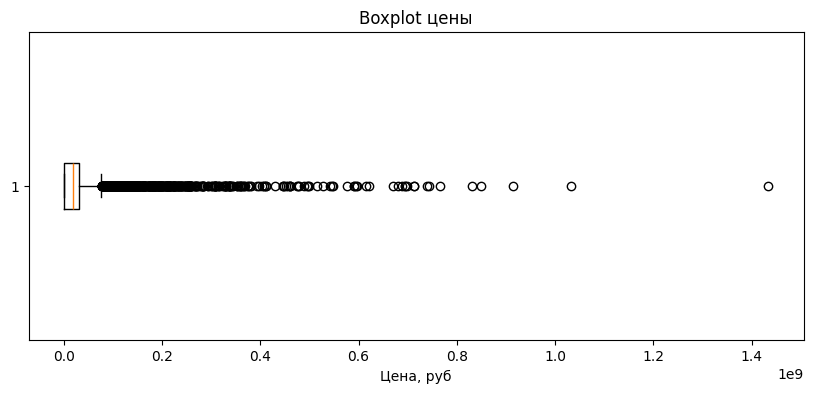

In [201]:
plt.figure(figsize=(10, 4))
plt.boxplot(df_clean['Цена'].dropna(), vert=False)
plt.xlabel('Цена, руб')
plt.title('Boxplot цены')
plt.show()

Явно есть сильные выбросы. Плюс цена квартиры не может быть 0 рублей. Возьмем за нижний порог - 100 000 рублей, за верхний 98-й квантиль, чтобы сохранить максимум объектов

Осталось объектов 5661 , удалено 3951


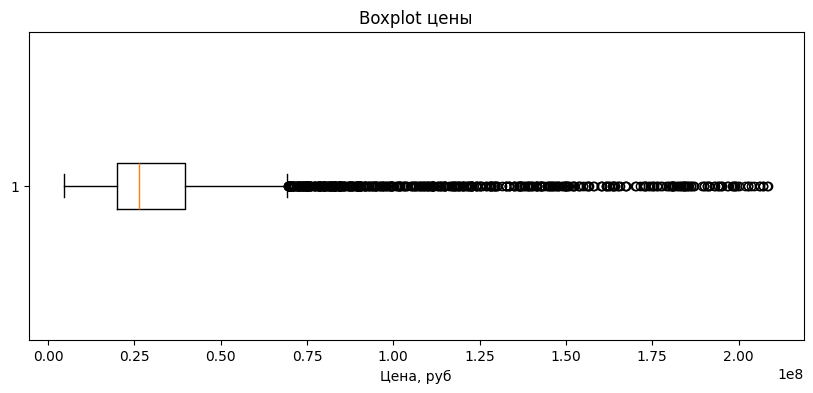

In [202]:
lower = 100_000
upper = df['Цена'].quantile(0.98)
n = len(df)
df_clean = df[(df['Цена'] >= lower) & (df['Цена'] <= upper)]
print('Осталось объектов', len(df_clean), ', удалено', n-len(df_clean))

plt.figure(figsize=(10, 4))
plt.boxplot(df_clean['Цена'].dropna(), vert=False)
plt.xlabel('Цена, руб')
plt.title('Boxplot цены')
plt.show()

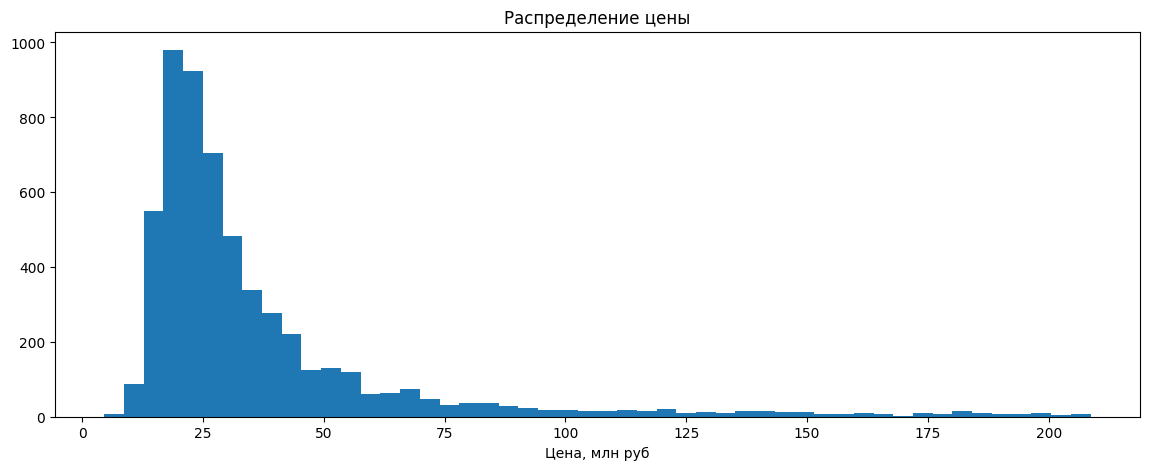

In [203]:
plt.figure(figsize=(14, 5))
plt.hist(df_clean['Цена']/10**6, bins=50)
plt.title('Распределение цены')
plt.xlabel('Цена, млн руб')
plt.show()


Большинство квартир стоят до 50 млн рублей. Есть небольшое количество дорогих объектов, которые тянут хвост вправо, но это нормально для рынка недвижимости.

Теперь перейдем к анализу метрик. Рассмотрим признаки, которые имеют среднюю и сильную корреляцию с каким-то отличным от самих признаком

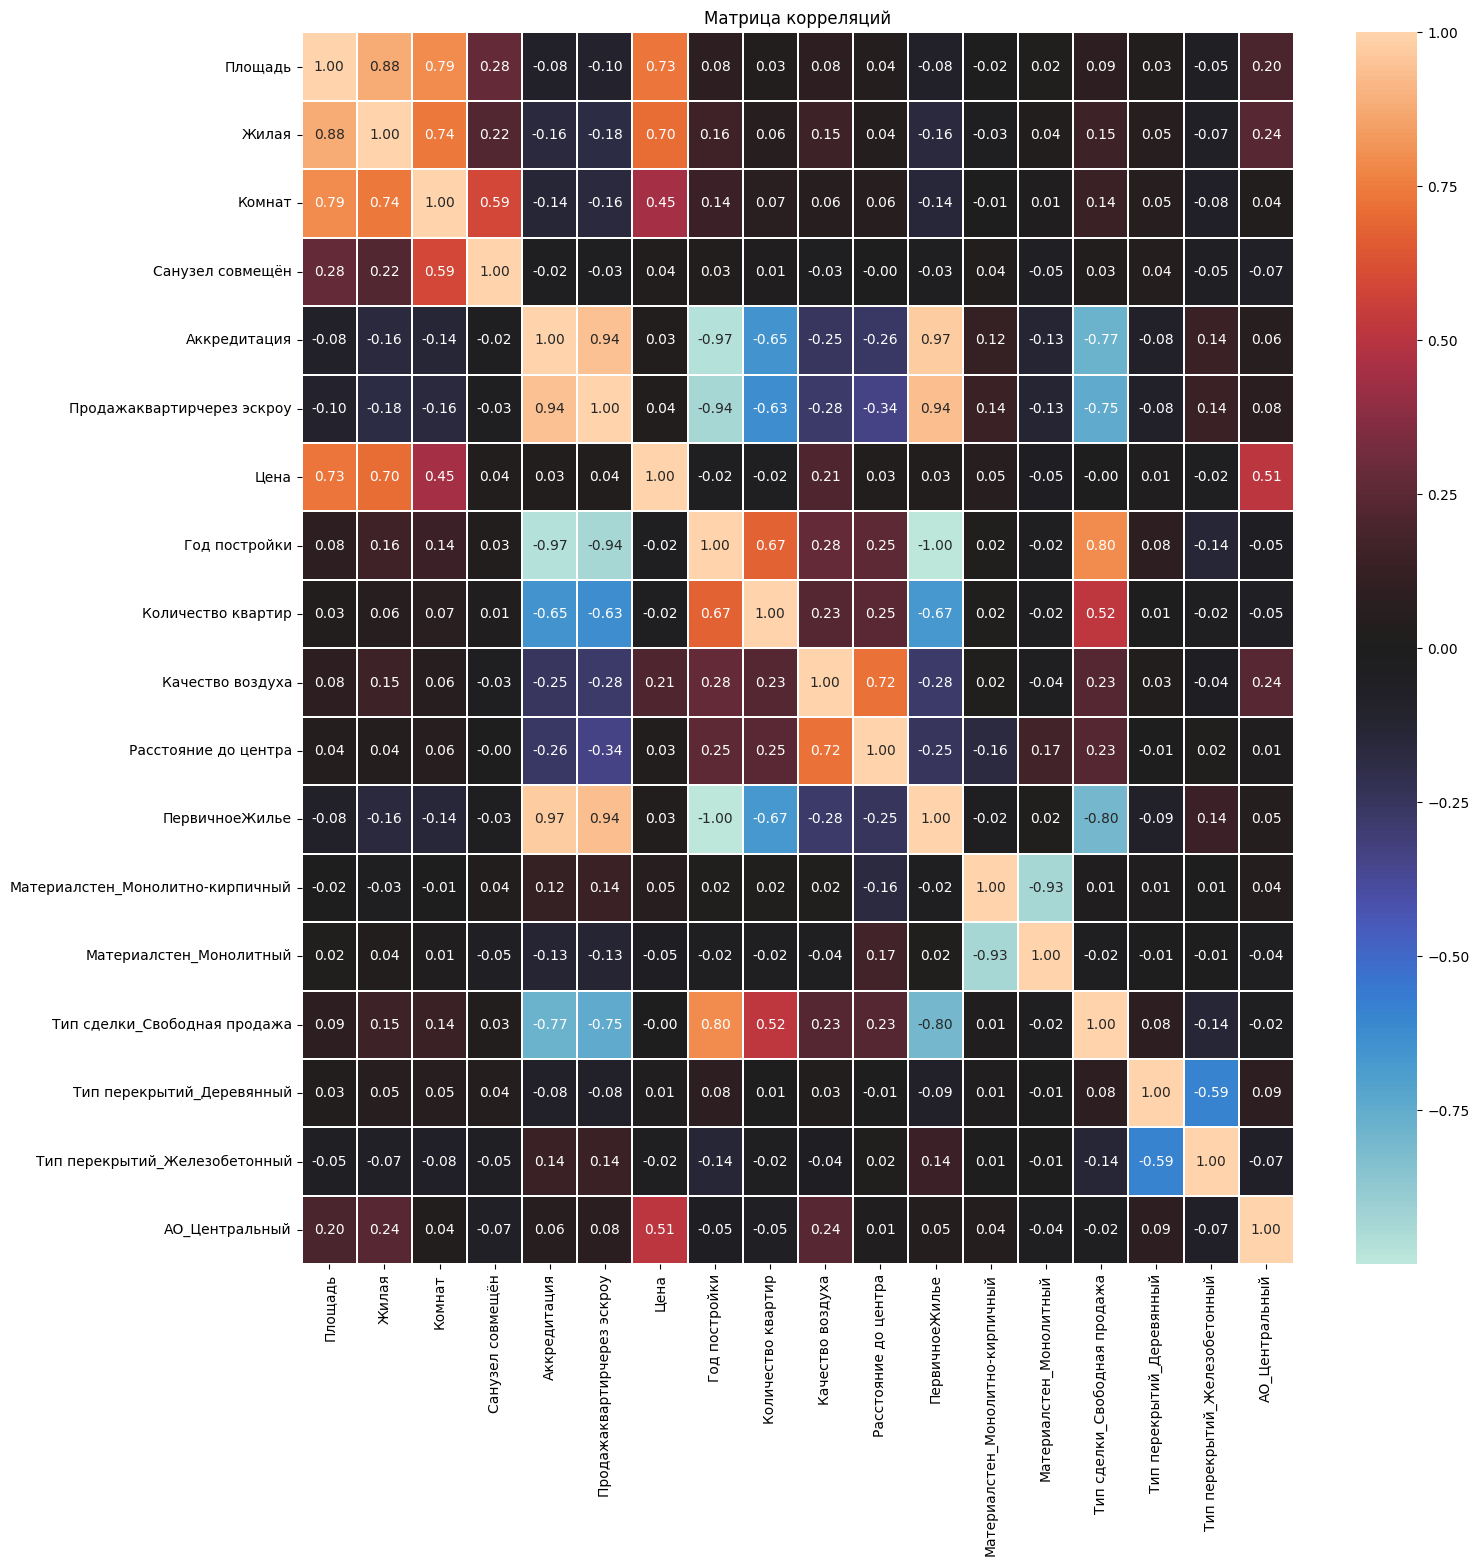

In [204]:
#corr_matrix = df_clean.drop(columns=['Метро', 'АО', 'Строительнаяготовность']).corr()
corr_matrix = df_clean.drop(columns=['Метро', 'Строительнаяготовность']).corr()

useful_cols = corr_matrix[(corr_matrix.abs() > 0.5).sum() > 1].index

plt.figure(figsize=(16, 16))
sns.heatmap(
    corr_matrix.loc[useful_cols, useful_cols],
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.3
)
plt.title('Матрица корреляций')
plt.show()


Матрица корреляций показывает достаточно много признаков сильно связаны друг с другом.

На цену больше всего влияет площадь (0.72), жилая площадь (0.67) и количество комнат (0.46). Логично, чем больше квартира, тем дороже.

Также видно что некоторые признаки почти полностью дублируют друг друга. Например, Аккредитация, Продажаквартирчерез эскроу, ПервичноеЖилье имеют корреляции 0.97–0.99, это один и тот же смысл.
Из этой тройки (Аккредитация, Продажаквартирчерез эскроу, ПервичноеЖилье) можно оставить один признак — ПервичноеЖилье как наиболее понятный.

Год постройки и ПервичноеЖилье — -1.0, сильная линейная зависимость
Материалстен_Монолитно-кирпичный и Материалстен_Монолитный — -0.93


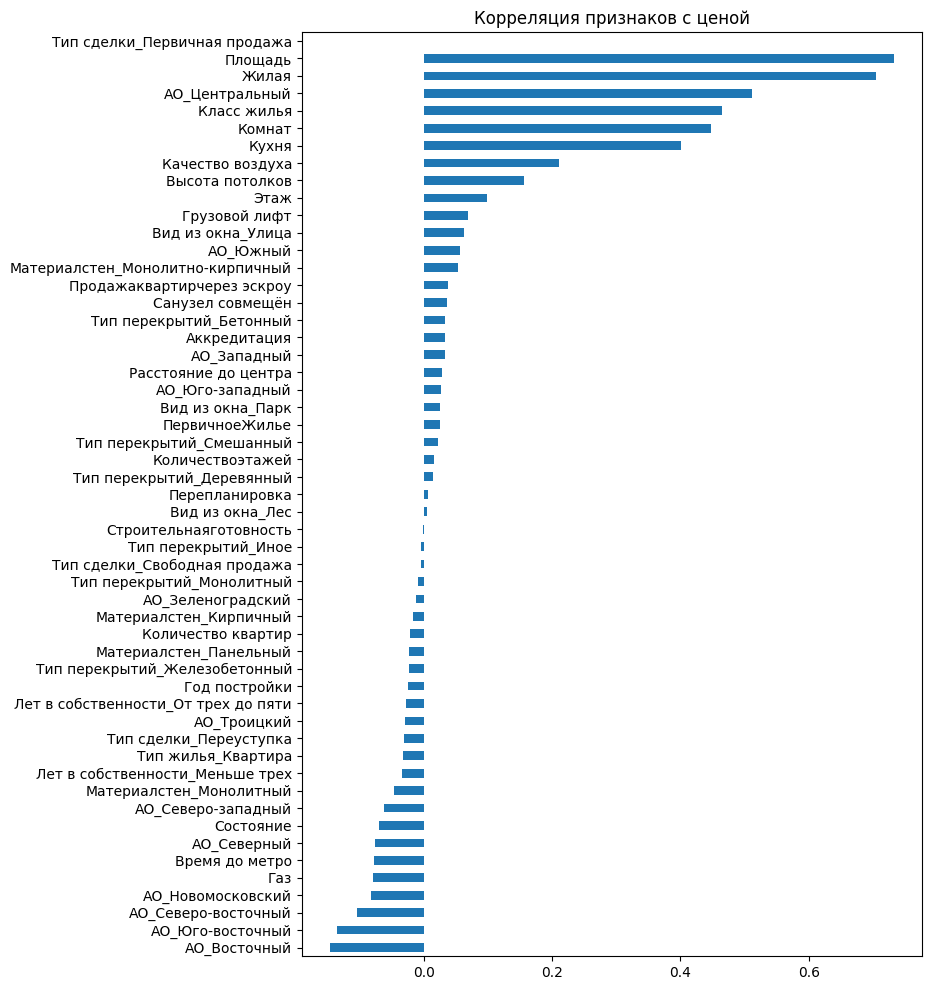

In [205]:
corr_target = df_clean.drop(columns=['Метро']).corr()['Цена'].drop('Цена').sort_values()

plt.figure(figsize=(8, 12))
corr_target.plot(kind='barh')
plt.title('Корреляция признаков с ценой')
plt.show()

Если более детально посмотреть на корреляции с ценой — сильнее всего влияют площадные признаки Площадь, Жилая, Кухня, Комнат. Далее идут характеристики жилья Класс жилья и Качество воздуха. Чуть слабее — Высота потолков и Этаж. Всё остальное практически не коррелирует с ценой линейно.
Интересно что Газ и Время до метро уходят в минус. Вероятно газифицированные дома это старый фонд, а далеко от метро дешевле.

Связи с округом сейчас оставим без внимания, их мы проанализируем дальше

Гипотеза 1. Чем больше площадь - тем выше цена. Уже видно из матрицы (0.72), но интересно посмотреть есть ли линейная зависимость или она ломается на очень больших площадях.

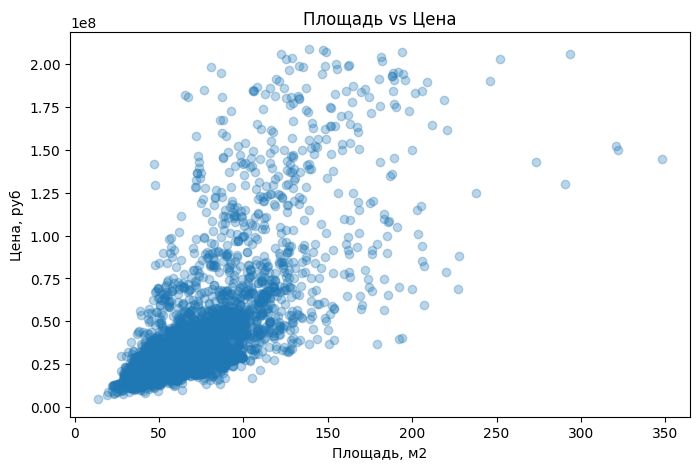

In [206]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['Площадь'], df_clean['Цена'], alpha=0.3)
plt.xlabel('Площадь, м2')
plt.ylabel('Цена, руб')
plt.title('Площадь vs Цена')
plt.show()

Гипотеза 2. Первичное жильё дороже вторичного при одинаковой площади — новостройки продаются с наценкой за новизну и инфраструктуру.

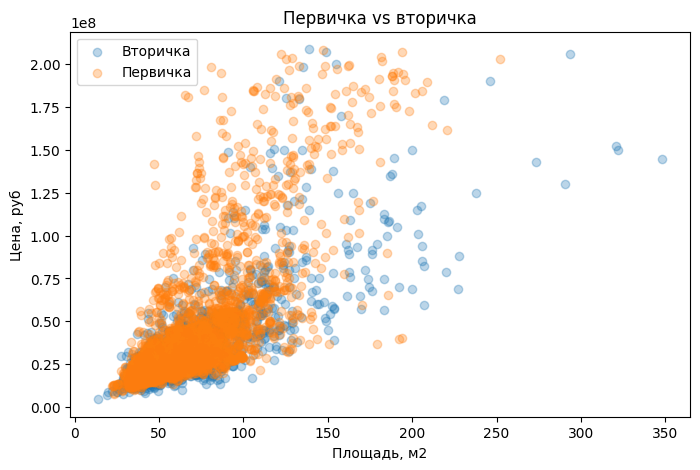

In [207]:
plt.figure(figsize=(8, 5))
for val, label in [(0, 'Вторичка'), (1, 'Первичка')]:
    mask = df_clean['ПервичноеЖилье'] == val
    plt.scatter(df_clean[mask]['Площадь'], df_clean[mask]['Цена'], alpha=0.3, label=label)

plt.xlabel('Площадь, м2')
plt.ylabel('Цена, руб')
plt.title('Первичка vs вторичка')
plt.legend()
plt.show()

Гипотеза 3. Чем ближе к метро — тем дороже квартира. Время до метро показывает -0.09 с ценой, но это слабо — возможно эффект нелинейный и лучше виден на группах (до 5 минут, 5–15, 15+).

/tmp/ipykernel_1039/3669498395.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Метро_группа'] = pd.cut(
/tmp/ipykernel_1039/3669498395.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('Метро_группа')['Цена'].median().plot(kind='bar')


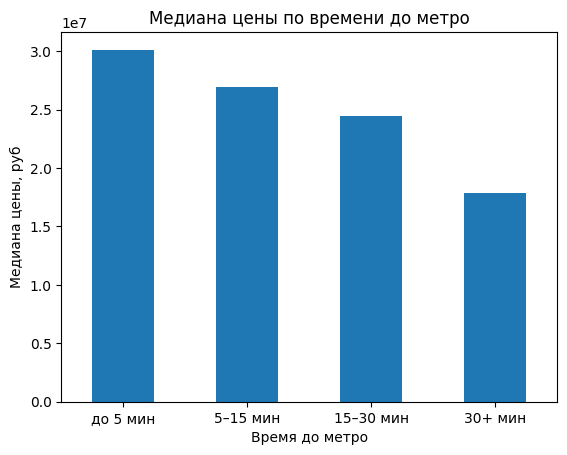

In [208]:
df_clean['Метро_группа'] = pd.cut(
    df_clean['Время до метро'],
    bins=[0, 5, 15, 30, 100],
    labels=['до 5 мин', '5–15 мин', '15–30 мин', '30+ мин']
)

df_clean.groupby('Метро_группа')['Цена'].median().plot(kind='bar')
plt.xlabel('Время до метро')
plt.ylabel('Медиана цены, руб')
plt.title('Медиана цены по времени до метро')
plt.xticks(rotation=0)
plt.show()

Теперь попробуем проанализировать влияние округа на некоторые ключевые параметры, как цена, площадь, кол-во комнат, время до метро, кол-во этажей и состояние квартиры

In [209]:
columns = [
    'Цена',
    'Площадь',
    'Комнат',
    'Время до метро',
    'Количествоэтажей',
    'Состояние'
]

okrug_columns = [col for col in df_clean.columns if col.startswith('АО_')]

df_corr = df_clean[columns + okrug_columns].copy()

In [210]:
corr_matrix = df_corr.corr()

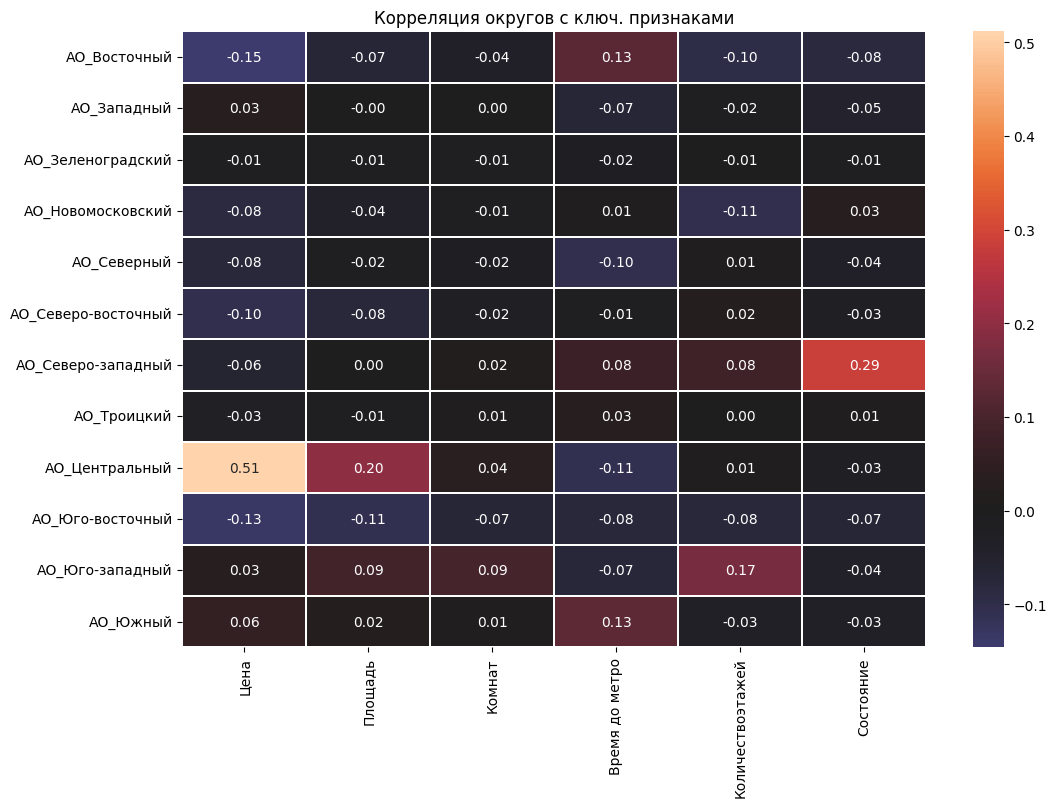

In [211]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix.loc[okrug_columns, columns],
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.3,
)

plt.title('Корреляция округов с ключ. признаками')
plt.show()


По этой корреляц. матрице можно сделать следующие выводы:

1. Заметно сильное влияние и округа цены только для объектов, у который округ - центральный (0.43)
Что удивительно, для Западного округа (который тоже считается дорогим) корреляция гораздо меньше (0.06)
А для восточного округа корреляция -(0.15), что значит, что этот округ дешевле среднего

2. Также в центральном округе корреляция с временом до метро (-0.16), в то время как в восточном - (0.12), т.е. в центральном округе метро в основном шаговой доступности, в то время как в восточом округе оно в среднем далеко от объектов

3. Состояние объектов в северо-западном округе в среднем лучше, чем в других районах. Скорее всего это связано с тем, что в последние 10 лет этот район активнее других застраивался и преобразовывался, поэтому состояние квартир там на текущий момент лучше, чем в других районах

4. Связь ключевых параметров и округа оказалась не особо существенной, большие корреляции не были замечены, из чего мы делаем вывод, что ключ. параметры объектов распределены более-менее равномерно по всем округам (кроме ЦАО)  

Теперь обратимся к переменной строительная готовность и попробуем проанализировать взаимосвязь (для новостроек) этого признака и цены

Проверим гипотезу: цена объекта и уровень его готовности - линейно зависимые величины (т.е. при увеличении уровня готовности объекта, не будет "резких" перепадов)

Построим график зависимости

<Figure size 800x500 with 0 Axes>

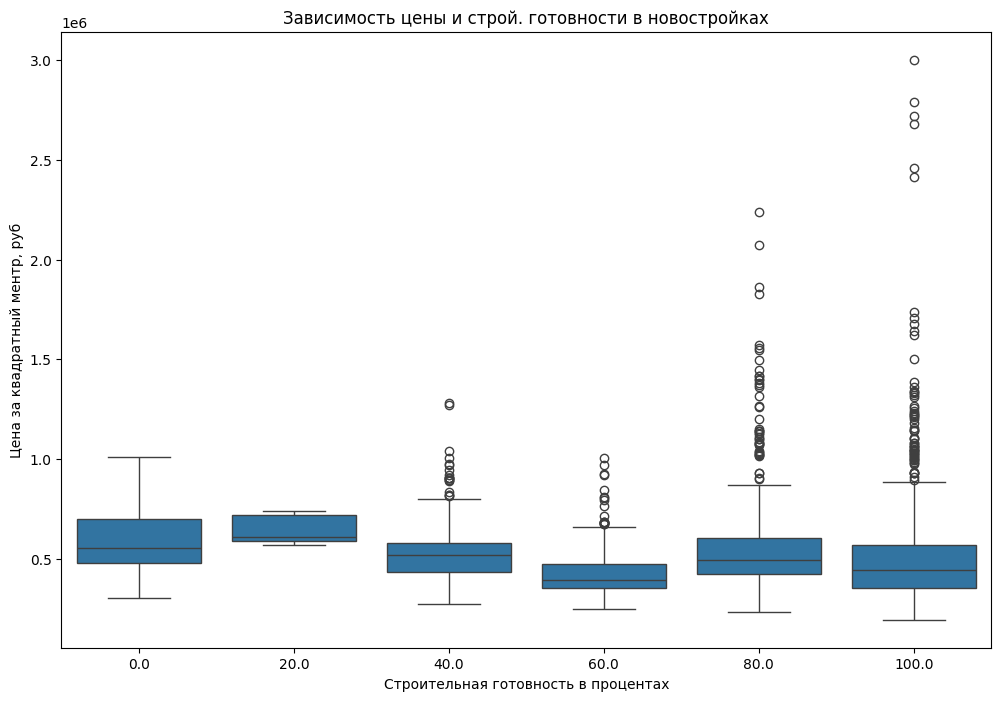

In [237]:
import seaborn as sns
plt.figure(figsize=(8, 5))

plot_df = df_clean.loc[(df_clean['Строительнаяготовность'].notna()) & (df_clean['ПервичноеЖилье'] == 1), ['Строительнаяготовность', 'Цена', 'Площадь']].copy()
plot_df['Цена_за_кв_м'] = plot_df['Цена'] / plot_df['Площадь']
plot_df['Готовность_группа'] = (plot_df['Строительнаяготовность']//20)*20
plt.figure(figsize=(12, 8))
sns.boxplot(data=plot_df, x='Готовность_группа', y='Цена_за_кв_м')
plt.xlabel('Строительная готовность в процентах')
plt.ylabel('Цена за квадратный ментр, руб')
plt.title('Зависимость цены и строй. готовности в новостройках')
plt.show()

Из графика становится ясно, что на каждом уровне готовности наблюдается широкий разброс цен, и нельзя подтвердить гипотезу о линейном возрастании цены квартиры (за квадратный метр)

Также заметим, что чем больше строй. готовность, тем больше "выбросов", что вероятней всего связано с тем, что на ранних этапах строй. готовности дорогие лоты не продаются в открытую, а презентуются на закрытых показах

Таким образом, делаем вывод, что цена на новостройки не определяется уровнем готовности, а опред. другими параметрами (площадь/расположение/цена и пр.)